# 📜 LSJ & Lewis-Short — Comparative Dictionary Analysis

## Greek (LSJ) and Latin (Lewis-Short) Lexica

This notebook analyzes the XML files from both lexica:

- **LSJ**: [gregorycrane/LSJLogeion](https://github.com/gregorycrane/lsjlogeion) — Liddell-Scott-Jones Greek-English Lexicon
- **LS**: Lewis & Short, *A Latin Dictionary* (Perseus / Logeion XML)

### Setup
```bash
git clone https://github.com/gregorycrane/LSJLogeion.git
# Place the LS XML file(s) in a known directory
pip install lxml matplotlib numpy pandas seaborn
```

In [1]:
import os, re, glob, json, unicodedata

from lxml import etree
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sns

matplotlib.rcParams['figure.figsize'] = (14, 7)
matplotlib.rcParams['font.size'] = 12

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    try:
        plt.style.use('seaborn-whitegrid')
    except OSError:
        pass

# ── Paths — adjust these ──────────────────────────────────────
LSJ_DIR  = '/Users/gcrane/github/LSJLogeion'          # directory with greatscott*.xml
LS_DIR = '/Users/gcrane/github/LewisShortLogeion'  # LS XML file(s)
#LS_FILES = ['/Users/gcrane/github/LatinLD']  # LS XML file(s)
# ──────────────────────────────────────────────────────────────

LSJ_XML = sorted(glob.glob(os.path.join(LSJ_DIR, 'greatscott*.xml')))
LS_FILES = sorted(glob.glob(os.path.join(LS_DIR, 'latindico*.xml')))
print(f'LSJ: found {len(LSJ_XML)} XML files')
print(f'LS:  found {len(LS_FILES)} XML file(s)')

LSJ: found 86 XML files
LS:  found 24 XML file(s)


## 1. Unified XML Parser

In [2]:
def parse_dict_file(filepath, dict_type='lsj'):
    """Parse one LSJ or LS XML file and return structured entry data.

    Parameters
    ----------
    filepath : str
        Path to XML file.
    dict_type : str
        'lsj' — entries live in <div2> elements
        'ls'  — entries live in <div1> elements
    """
    parser = etree.XMLParser(recover=True, huge_tree=True)
    tree = etree.parse(filepath, parser)
    root = tree.getroot()

    entry_tag = 'div2' if dict_type == 'lsj' else 'div1'
    entries = root.findall(f'.//{entry_tag}')

    # For LS, the target language in <foreign> is Latin ('la');
    # for LSJ it is Greek ('grc'/'greek').
    target_langs = {'grc', 'greek'} if dict_type == 'lsj' else {'la', 'latin'}

    # Unicode ranges: Greek (LSJ) vs Latin supplement (LS)
    if dict_type == 'lsj':
        def count_target_chars(text):
            return sum(1 for ch in text
                       if 0x0370 <= ord(ch) <= 0x03FF
                       or 0x1F00 <= ord(ch) <= 0x1FFF)
    else:
        # For LS we count Latin characters (basic + extended)
        def count_target_chars(text):
            return sum(1 for ch in text
                       if 0x0041 <= ord(ch) <= 0x007A  # A-z
                       or 0x00C0 <= ord(ch) <= 0x024F)  # Latin Extended

    result = []
    for entry in entries:
        key = entry.get('key', '')

        head = entry.find('.//head')
        headword = ''.join(head.itertext()).strip() if head is not None else key

        full_text = ''.join(entry.itertext())

        senses = entry.findall('.//sense')
        bibls  = entry.findall('.//bibl')

        authors = []
        for a in entry.findall('.//author'):
            t = ''.join(a.itertext()).strip()
            if t:
                authors.append(t)

        works = []
        for b in bibls:
            a_el = b.find('.//author')
            t_el = b.find('.//title')
            a_t = ''.join(a_el.itertext()).strip() if a_el is not None else ''
            w_t = ''.join(t_el.itertext()).strip() if t_el is not None else ''
            if a_t and w_t:
                works.append(f'{a_t}, {w_t}')
            elif a_t:
                works.append(a_t)

        tgt_chars = count_target_chars(full_text)

        tgt_words_in_foreign = []
        for f in entry.findall('.//foreign'):
            if f.get('lang', '') in target_langs:
                t = ''.join(f.itertext()).strip()
                if t:
                    tgt_words_in_foreign.extend(t.split())

        quotes      = entry.findall('.//quote')
        etyms       = entry.findall('.//etym')
        pos_els     = entry.findall('.//pos')
        pos_list    = [''.join(p.itertext()).strip() for p in pos_els]

        dialect_els = entry.findall('.//gram[@type="dialect"]')
        dialects    = [''.join(d.itertext()).strip() for d in dialect_els]

        sense_levels = [s.get('level', '') for s in senses]

        result.append({
            'key': key,
            'headword': headword,
            'text_len': len(full_text),
            'n_senses': len(senses),
            'sense_levels': sense_levels,
            'n_bibls': len(bibls),
            'authors': authors,
            'works': works,
            'target_chars': tgt_chars,
            'target_words': len(tgt_words_in_foreign),
            'n_quotes': len(quotes),
            'n_etyms': len(etyms),
            'pos': pos_list,
            'dialects': dialects,
        })

    return result

## 2. Parse All Files

In [3]:
# ── LSJ ────────────────────────────────────────────────────────
lsj_entries = []
for i, f in enumerate(LSJ_XML):
    lsj_entries.extend(parse_dict_file(f, dict_type='lsj'))
    if (i + 1) % 10 == 0:
        print(f'  LSJ: parsed {i+1}/{len(LSJ_XML)} files, {len(lsj_entries):,} entries')
print(f'  LSJ total: {len(lsj_entries):,} entries')

# ── LS ─────────────────────────────────────────────────────────
ls_entries = []
for i, f in enumerate(LS_FILES):
    ls_entries.extend(parse_dict_file(f, dict_type='ls'))
    print(f'  LS: parsed {i+1}/{len(LS_FILES)} files, {len(ls_entries):,} entries')
print(f'  LS total: {len(ls_entries):,} entries')

df_lsj = pd.DataFrame(lsj_entries)
df_ls  = pd.DataFrame(ls_entries)

print(f'\nLSJ DataFrame shape: {df_lsj.shape}')
print(f'LS  DataFrame shape: {df_ls.shape}')

  LSJ: parsed 10/86 files, 18,154 entries
  LSJ: parsed 20/86 files, 30,216 entries
  LSJ: parsed 30/86 files, 46,319 entries
  LSJ: parsed 40/86 files, 58,433 entries
  LSJ: parsed 50/86 files, 71,917 entries
  LSJ: parsed 60/86 files, 86,563 entries
  LSJ: parsed 70/86 files, 98,617 entries
  LSJ: parsed 80/86 files, 112,629 entries
  LSJ total: 117,107 entries
  LS: parsed 1/24 files, 4,769 entries
  LS: parsed 2/24 files, 5,932 entries
  LS: parsed 3/24 files, 12,274 entries
  LS: parsed 4/24 files, 15,059 entries
  LS: parsed 5/24 files, 17,492 entries
  LS: parsed 6/24 files, 19,222 entries
  LS: parsed 7/24 files, 20,118 entries
  LS: parsed 8/24 files, 21,297 entries
  LS: parsed 9/24 files, 25,494 entries
  LS: parsed 10/24 files, 25,502 entries
  LS: parsed 11/24 files, 27,468 entries
  LS: parsed 12/24 files, 30,380 entries
  LS: parsed 13/24 files, 31,618 entries
  LS: parsed 14/24 files, 33,336 entries
  LS: parsed 15/24 files, 39,895 entries
  LS: parsed 16/24 files, 40,3

## 3. Summary Statistics

In [4]:
def print_summary(df, label):
    """Print summary statistics for one dictionary."""
    print(f'{"=" * 60}')
    print(f'{label} — SUMMARY STATISTICS')
    print(f'{"=" * 60}')
    print(f'  Entries:                  {len(df):>10,}')
    print(f'  Citations (bibl):         {df["n_bibls"].sum():>10,}')
    print(f'  Target-lang words:        {df["target_words"].sum():>10,}')
    print(f'  Target-lang characters:   {df["target_chars"].sum():>10,}')
    print(f'  Senses:                   {df["n_senses"].sum():>10,}')
    uniq_auth = len(set(a for al in df['authors'] for a in al))
    print(f'  Unique authors cited:     {uniq_auth:>10,}')
    print(f'  Entries with ≥1 sense:    {(df["n_senses"]>0).sum():>10,}  ({100*(df["n_senses"]>0).mean():.1f}%)')
    print(f'  Entries with ≥1 citation: {(df["n_bibls"]>0).sum():>10,}  ({100*(df["n_bibls"]>0).mean():.1f}%)')
    print(f'  Quoted passages:          {df["n_quotes"].sum():>10,}')
    print(f'  Etymology elements:       {df["n_etyms"].sum():>10,}')
    print(f'  Avg senses / entry:       {df["n_senses"].mean():>10.2f}')
    print(f'  Avg citations / entry:    {df["n_bibls"].mean():>10.2f}')
    print(f'  Median entry length:      {df["text_len"].median():>10.0f} chars')
    print(f'  Mean entry length:        {df["text_len"].mean():>10.0f} chars')

print_summary(df_lsj, 'LSJ (Greek)')
print_summary(df_ls,  'Lewis-Short (Latin)')

LSJ (Greek) — SUMMARY STATISTICS
  Entries:                     117,107
  Citations (bibl):            455,214
  Target-lang words:           331,829
  Target-lang characters:    5,742,086
  Senses:                      159,426
  Unique authors cited:          1,566
  Entries with ≥1 sense:       101,417  (86.6%)
  Entries with ≥1 citation:     88,985  (76.0%)
  Quoted passages:             157,632
  Etymology elements:           10,387
  Avg senses / entry:             1.36
  Avg citations / entry:          3.89
  Median entry length:              77 chars
  Mean entry length:               197 chars
Lewis-Short (Latin) — SUMMARY STATISTICS
  Entries:                      51,674
  Citations (bibl):            386,904
  Target-lang words:               412
  Target-lang characters:   15,034,339
  Senses:                       94,980
  Unique authors cited:            372
  Entries with ≥1 sense:        42,746  (82.7%)
  Entries with ≥1 citation:     41,660  (80.6%)
  Quoted passages:  

## 4. Side-by-Side Comparison

In [5]:
def make_comparison(df_a, df_b, label_a='LSJ', label_b='LS'):
    """Build a comparison DataFrame of key metrics."""
    def metrics(df):
        return {
            'Entries':              len(df),
            'Citations':            int(df['n_bibls'].sum()),
            'Senses':               int(df['n_senses'].sum()),
            'Unique authors':       len(set(a for al in df['authors'] for a in al)),
            'Quoted passages':      int(df['n_quotes'].sum()),
            'Etymology elements':   int(df['n_etyms'].sum()),
            'Entries w/ ≥1 sense':  int((df['n_senses'] > 0).sum()),
            'Entries w/ ≥1 cit.':   int((df['n_bibls'] > 0).sum()),
            'Avg senses/entry':     round(df['n_senses'].mean(), 2),
            'Avg citations/entry':  round(df['n_bibls'].mean(), 2),
            'Median entry len':     int(df['text_len'].median()),
            'Mean entry len':       int(df['text_len'].mean()),
        }

    m_a, m_b = metrics(df_a), metrics(df_b)
    comp = pd.DataFrame({label_a: m_a, label_b: m_b})
    comp['Ratio (A/B)'] = comp[label_a] / comp[label_b]
    return comp

comp = make_comparison(df_lsj, df_ls)
print(comp.to_string())

                           LSJ         LS  Ratio (A/B)
Entries              117107.00   51674.00     2.266265
Citations            455214.00  386904.00     1.176555
Senses               159426.00   94980.00     1.678522
Unique authors         1566.00     372.00     4.209677
Quoted passages      157632.00  222613.00     0.708099
Etymology elements    10387.00   24119.00     0.430656
Entries w/ ≥1 sense  101417.00   42746.00     2.372549
Entries w/ ≥1 cit.    88985.00   41660.00     2.135982
Avg senses/entry          1.36       1.84     0.739130
Avg citations/entry       3.89       7.49     0.519359
Median entry len         77.00     131.00     0.587786
Mean entry len          196.00     471.00     0.416136


## 5. Most Commonly Cited Authors

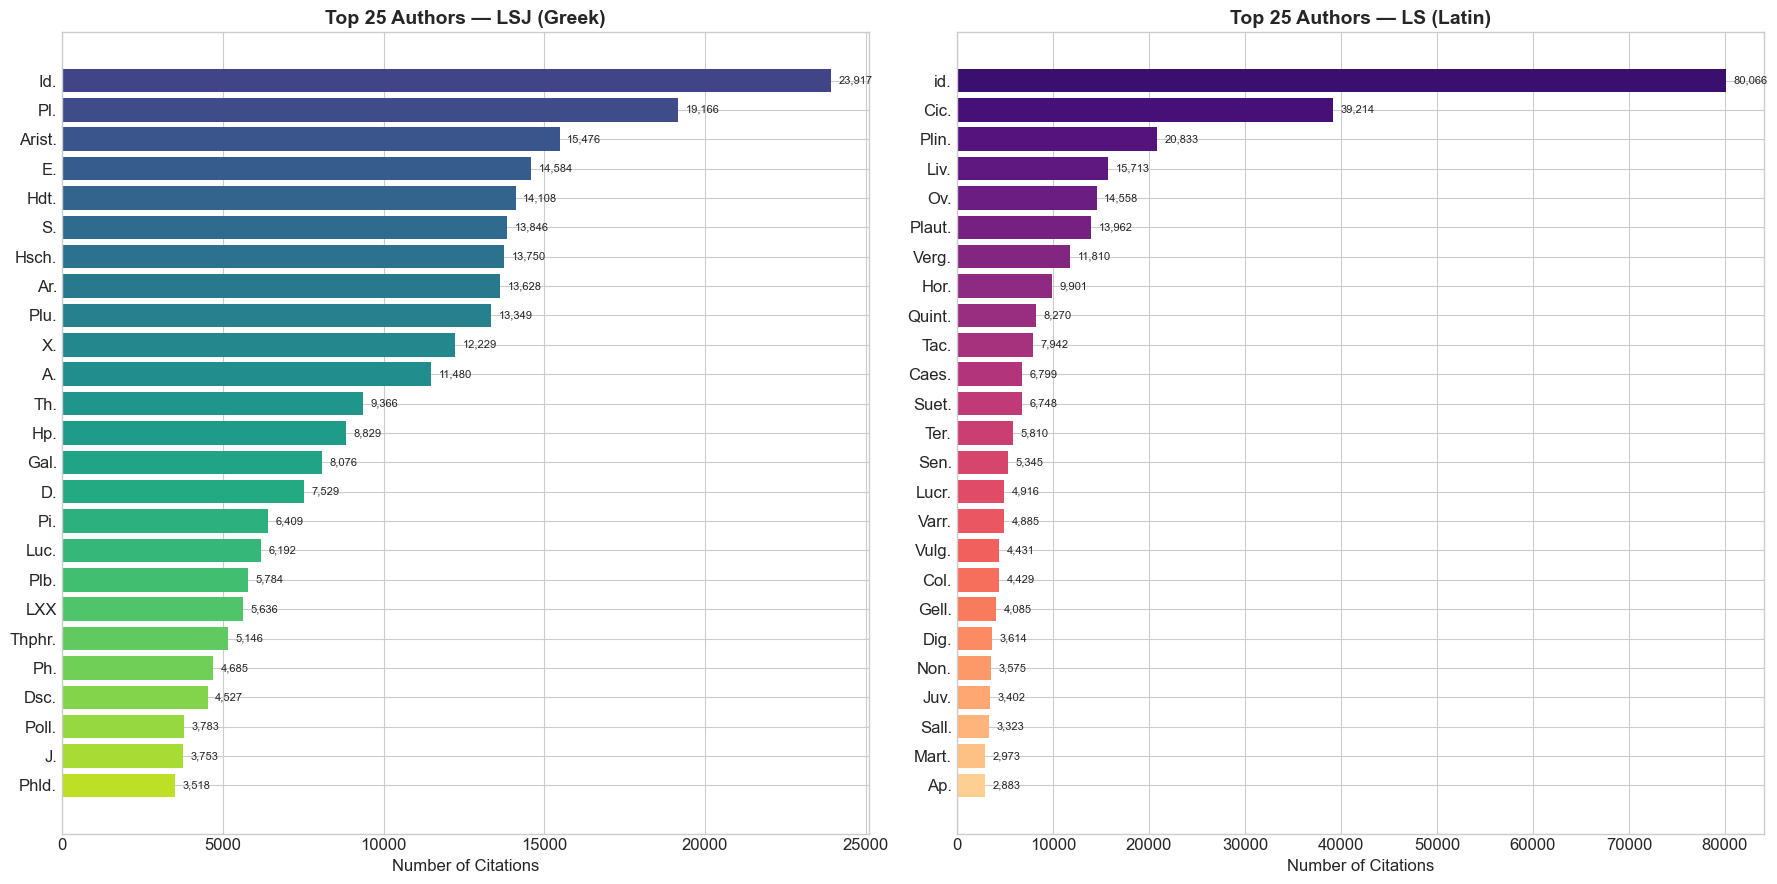

In [6]:
def get_author_counts(df):
    c = Counter()
    for al in df['authors']:
        c.update(al)
    return c

lsj_auth = get_author_counts(df_lsj)
ls_auth  = get_author_counts(df_ls)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9))

for ax, counts, title, cmap in [
    (ax1, lsj_auth, 'Top 25 Authors — LSJ (Greek)', 'viridis'),
    (ax2, ls_auth,  'Top 25 Authors — LS (Latin)',   'magma'),
]:
    top = counts.most_common(25)
    labels, vals = zip(*top)
    colors = plt.get_cmap(cmap)(np.linspace(0.2, 0.9, len(labels)))
    bars = ax.barh(range(len(labels)), vals, color=colors)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel('Number of Citations')
    ax.set_title(title, fontsize=14, fontweight='bold')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width() + max(vals)*0.01,
                bar.get_y() + bar.get_height()/2,
                f'{v:,}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 6. Most Cited Works

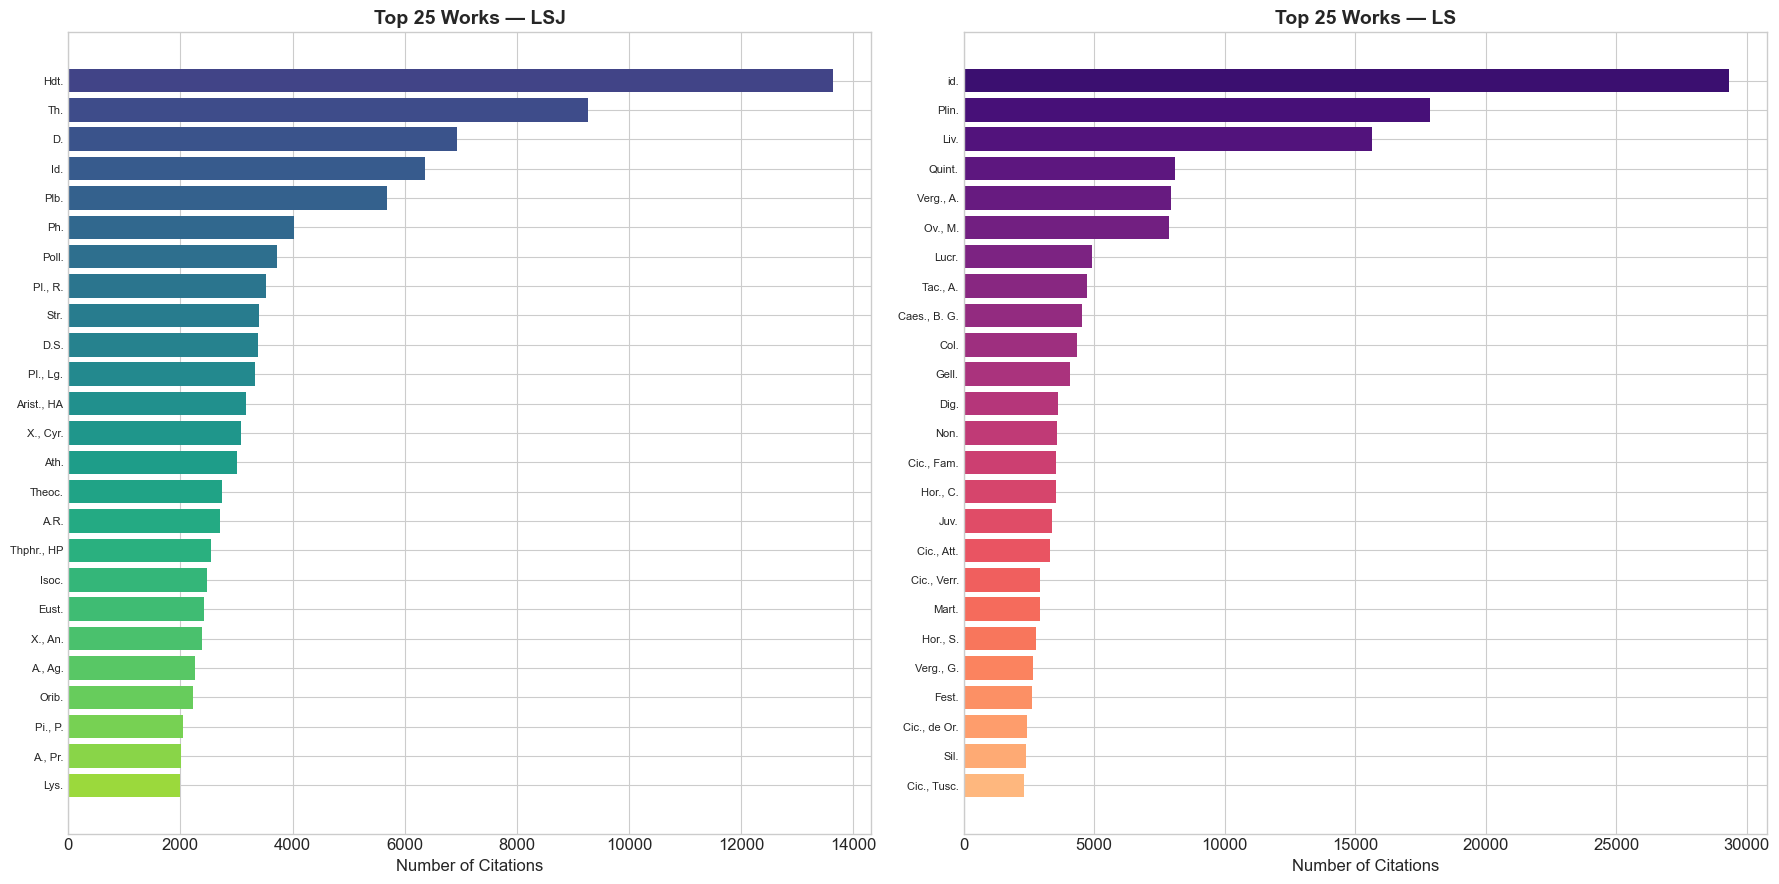

In [7]:
def get_work_counts(df):
    c = Counter()
    for wl in df['works']:
        c.update(wl)
    return c

lsj_works = get_work_counts(df_lsj)
ls_works  = get_work_counts(df_ls)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9))

for ax, counts, title, cmap in [
    (ax1, lsj_works, 'Top 25 Works — LSJ', 'viridis'),
    (ax2, ls_works,  'Top 25 Works — LS',  'magma'),
]:
    top = counts.most_common(25)
    if not top:
        ax.text(0.5, 0.5, 'No work-level data', ha='center', va='center',
                transform=ax.transAxes, fontsize=14)
        ax.set_title(title, fontsize=14, fontweight='bold')
        continue
    labels, vals = zip(*top)
    colors = plt.get_cmap(cmap)(np.linspace(0.2, 0.85, len(labels)))
    bars = ax.barh(range(len(labels)), vals, color=colors)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('Number of Citations')
    ax.set_title(title, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Entry Length Distributions

/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/numpy/core/_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order)
/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/numpy/core/_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order)


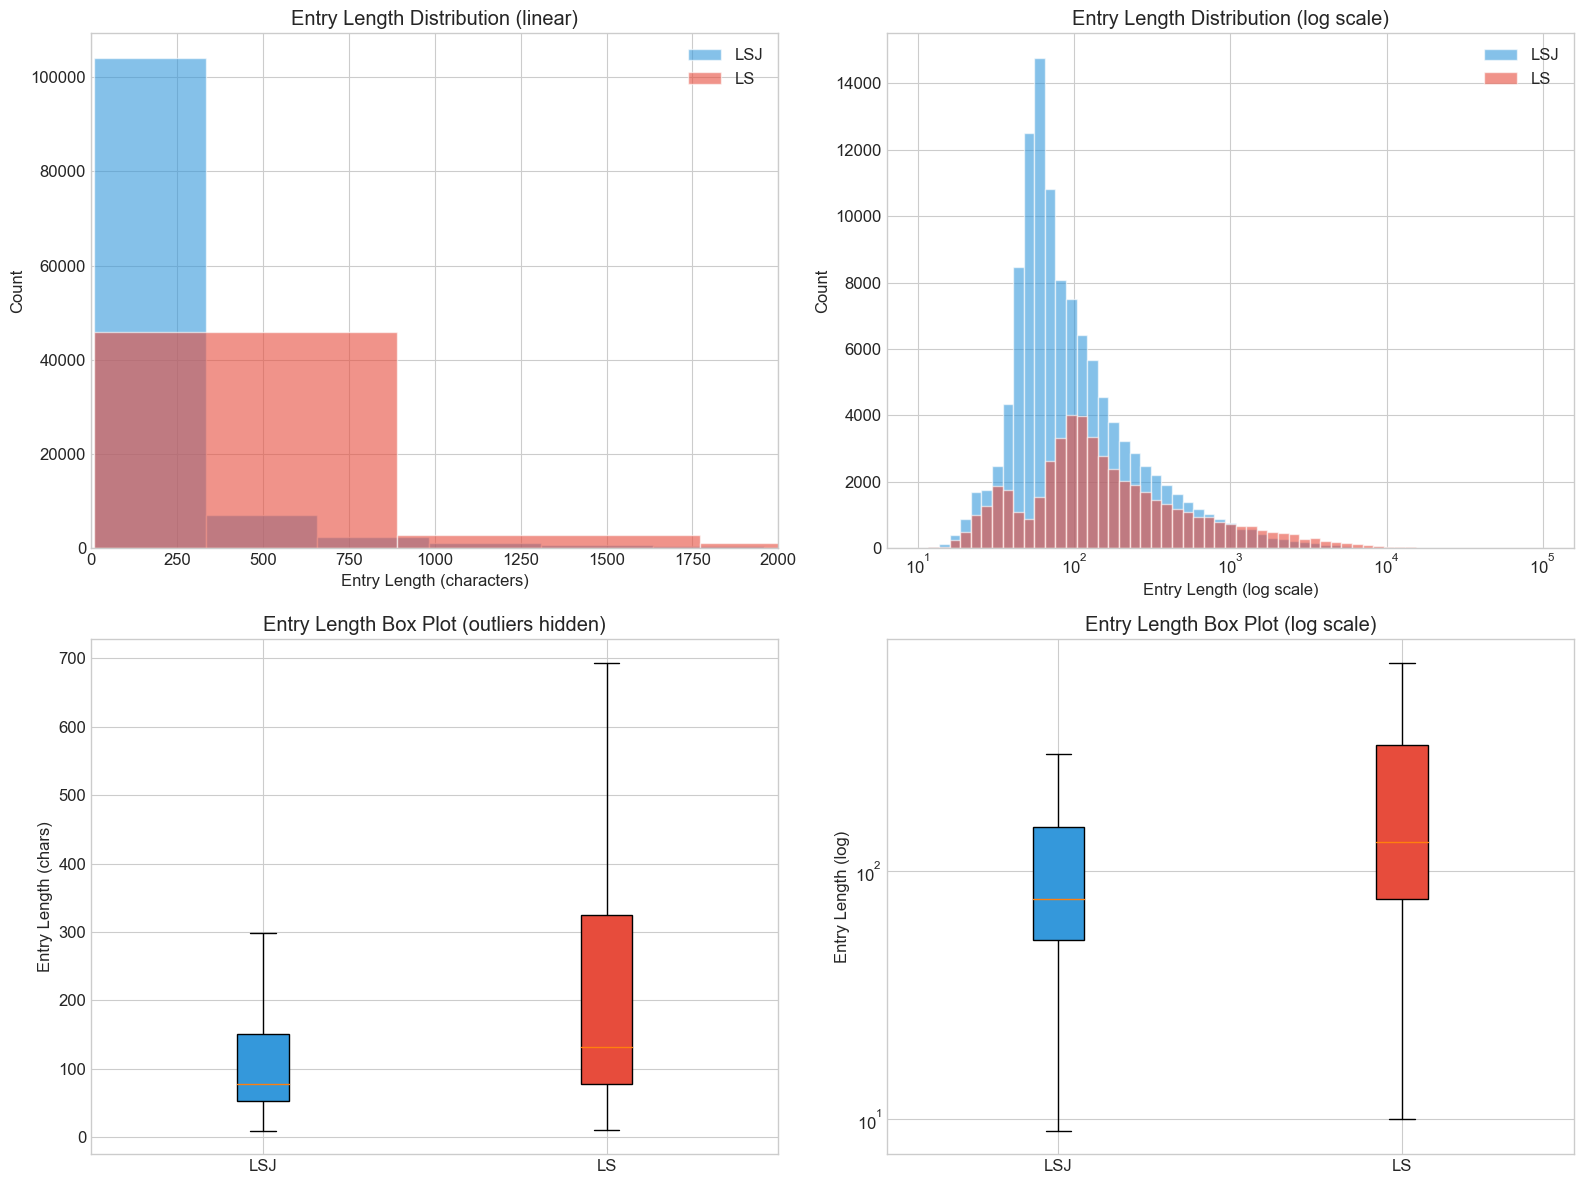

Top 30 longest entries — LSJ:
  λόγος                           32,516 chars   64 senses   658 citations
  ἐπί                             30,767 chars   93 senses   659 citations
  πρός                            30,166 chars   52 senses   597 citations
  φέρω                            28,556 chars   54 senses   625 citations
  τε                              25,118 chars   46 senses   464 citations
  τίθημι                          23,933 chars   51 senses   545 citations
  παρά                            22,890 chars   63 senses   412 citations
  ὡς                              22,806 chars   75 senses   373 citations
  ὁ                               22,257 chars   61 senses   332 citations
  ἔχω                             21,744 chars   60 senses   572 citations
  ὑπό                             20,721 chars   39 senses   392 citations
  εἰμί                            19,136 chars   40 senses   400 citations
  ἄν                              18,852 chars   56 senses   232 citat

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Row 1: overlaid histograms
ax = axes[0, 0]
ax.hist(df_lsj['text_len'], bins=100, color='#3498db', alpha=0.6, label='LSJ', edgecolor='white')
ax.hist(df_ls['text_len'],  bins=100, color='#e74c3c', alpha=0.6, label='LS',  edgecolor='white')
ax.set_xlabel('Entry Length (characters)')
ax.set_ylabel('Count')
ax.set_title('Entry Length Distribution (linear)')
ax.set_xlim(0, 2000)
ax.legend()

ax = axes[0, 1]
bins = np.logspace(1, 5, 60)
ax.hist(df_lsj['text_len'], bins=bins, color='#3498db', alpha=0.6, label='LSJ', edgecolor='white')
ax.hist(df_ls['text_len'],  bins=bins, color='#e74c3c', alpha=0.6, label='LS',  edgecolor='white')
ax.set_xscale('log')
ax.set_xlabel('Entry Length (log scale)')
ax.set_ylabel('Count')
ax.set_title('Entry Length Distribution (log scale)')
ax.legend()

# Row 2: box plots
ax = axes[1, 0]
data_box = [df_lsj['text_len'], df_ls['text_len']]
bp = ax.boxplot(data_box, labels=['LSJ', 'LS'], patch_artist=True, showfliers=False)
bp['boxes'][0].set_facecolor('#3498db')
bp['boxes'][1].set_facecolor('#e74c3c')
ax.set_ylabel('Entry Length (chars)')
ax.set_title('Entry Length Box Plot (outliers hidden)')

ax = axes[1, 1]
bp = ax.boxplot(data_box, labels=['LSJ', 'LS'], patch_artist=True, showfliers=False)
bp['boxes'][0].set_facecolor('#3498db')
bp['boxes'][1].set_facecolor('#e74c3c')
ax.set_yscale('log')
ax.set_ylabel('Entry Length (log)')
ax.set_title('Entry Length Box Plot (log scale)')

plt.tight_layout()
plt.show()

# Top entries per dict
for label, d in [('LSJ', df_lsj), ('LS', df_ls)]:
    print(f'Top 30 longest entries — {label}:')
    for _, row in d.nlargest(30, 'text_len').iterrows():
        print(f'  {row["headword"]:30s}  {row["text_len"]:6,} chars  '
              f'{row["n_senses"]:3d} senses  {row["n_bibls"]:4d} citations')

## 8. Senses per Entry

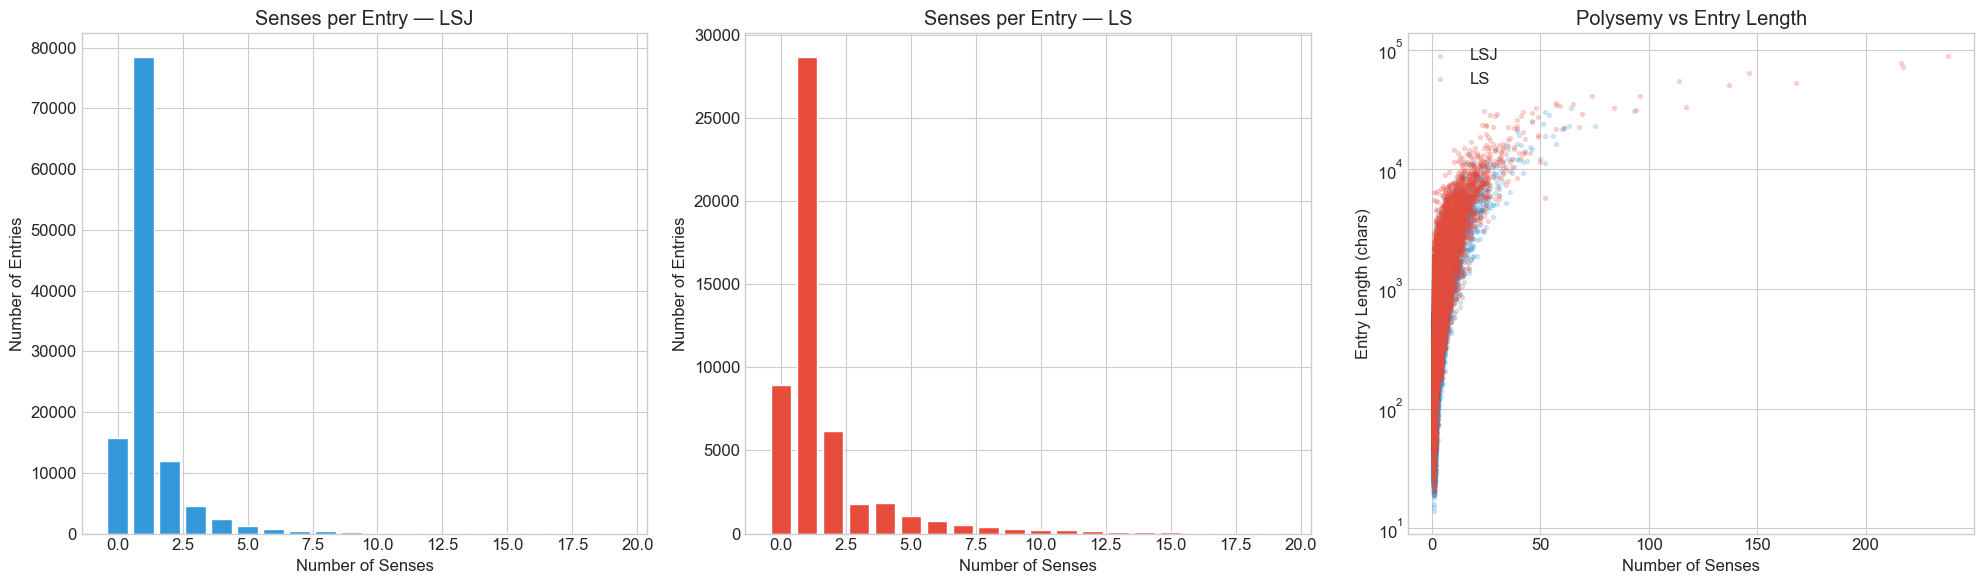

LSJ:
  0 senses:   15,690 (13.4%)
  1 sense:    78,435 (67.0%)
  2-5:        20,160
  6+:          2,822
  Most polysemous:
    ἐπί                        93 senses
    ὡς                         75 senses
    λόγος                      64 senses
    παρά                       63 senses
    ὁ                          61 senses
    ἔχω                        60 senses
    ὅς                         57 senses
    ἄν                         56 senses
    φέρω                       54 senses
    εἰ                         52 senses
LS:
  0 senses:    8,928 (17.3%)
  1 sense:    28,656 (55.5%)
  2-5:        10,771
  6+:          3,319
  Most polysemous:
    volo                      238 senses
    contra                    217 senses
    cum                       216 senses
    tum                       168 senses
    suus                      146 senses
    solvo                     137 senses
    bonus                     117 senses
    ut                        114 senses
    censeo     

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Histograms per dict
for ax, d, label, color in [
    (axes[0], df_lsj, 'LSJ', '#3498db'),
    (axes[1], df_ls,  'LS',  '#e74c3c'),
]:
    sd = d['n_senses'].value_counts().sort_index()
    ax.bar(sd.index[:20], sd.values[:20], color=color, edgecolor='white')
    ax.set_xlabel('Number of Senses')
    ax.set_ylabel('Number of Entries')
    ax.set_title(f'Senses per Entry — {label}')

# Polysemy vs length overlay
ax = axes[2]
for d, label, color in [(df_lsj, 'LSJ', '#3498db'), (df_ls, 'LS', '#e74c3c')]:
    poly = d[d['n_senses'] > 0]
    ax.scatter(poly['n_senses'], poly['text_len'], alpha=0.2, s=8, c=color, label=label)
ax.set_xlabel('Number of Senses')
ax.set_ylabel('Entry Length (chars)')
ax.set_title('Polysemy vs Entry Length')
ax.set_yscale('log')
ax.legend()

plt.tight_layout()
plt.show()

for label, d in [('LSJ', df_lsj), ('LS', df_ls)]:
    print(f'{label}:')
    print(f'  0 senses:  {(d["n_senses"]==0).sum():>7,} ({100*(d["n_senses"]==0).mean():.1f}%)')
    print(f'  1 sense:   {(d["n_senses"]==1).sum():>7,} ({100*(d["n_senses"]==1).mean():.1f}%)')
    print(f'  2-5:       {((d["n_senses"]>=2)&(d["n_senses"]<=5)).sum():>7,}')
    print(f'  6+:        {(d["n_senses"]>=6).sum():>7,}')
    print(f'  Most polysemous:')
    for _, row in d.nlargest(10, 'n_senses').iterrows():
        print(f'    {row["headword"]:25s} {row["n_senses"]:3d} senses')

## 9. Dialect Tags

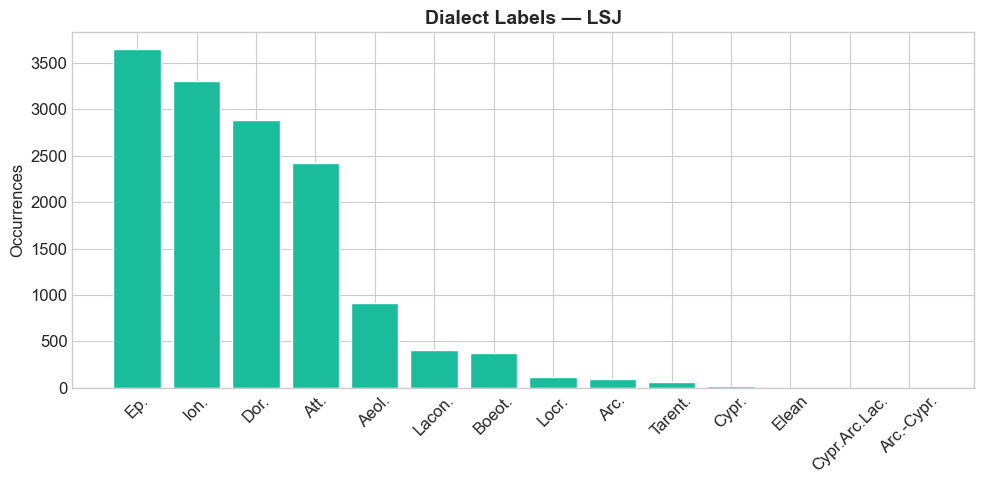

LS: no dialect tags found


In [10]:
for label, d, color in [('LSJ', df_lsj, '#1abc9c'), ('LS', df_ls, '#e67e22')]:
    dc = Counter()
    for dl in d['dialects']:
        dc.update(dl)

    if dc:
        top_d = dc.most_common(15)
        labels_d, vals = zip(*top_d)

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(labels_d, vals, color=color, edgecolor='white')
        ax.set_ylabel('Occurrences')
        ax.set_title(f'Dialect Labels — {label}', fontsize=14, fontweight='bold')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print(f'{label}: no dialect tags found')

## 10. Additional Lexicographic Statistics

Hapax citanda, cross-references, etymology coverage, POS tags, sense hierarchy.

In [11]:
for label, d in [('LSJ', df_lsj), ('LS', df_ls)]:
    print(f'{"=" * 60}')
    print(f'{label} — ADDITIONAL STATISTICS')
    print(f'{"=" * 60}')

    hapax = (d['n_bibls'] == 1).sum()
    print(f'  Hapax citanda (1 citation):       {hapax:>7,} ({100*hapax/len(d):.1f}%)')

    xref = ((d['n_senses'] == 0) & (d['text_len'] < 60)).sum()
    print(f'  Short cross-ref entries:          {xref:>7,} ({100*xref/len(d):.1f}%)')

    has_etym = (d['n_etyms'] > 0).sum()
    print(f'  Entries with etymology:           {has_etym:>7,} ({100*has_etym/len(d):.1f}%)')

    has_quotes = (d['n_quotes'] > 0).sum()
    print(f'  Entries with quoted passages:     {has_quotes:>7,} ({100*has_quotes/len(d):.1f}%)')

    d_copy = d.copy()
    d_copy['cit_density'] = d_copy['n_bibls'] / (d_copy['text_len'] / 100)
    print(f'  Mean citation density (per 100c): {d_copy["cit_density"].mean():.2f}')

    # POS
    pos_c = Counter()
    for pl in d['pos']:
        pos_c.update(pl)
    print(f'  Explicit POS tags:                {sum(pos_c.values()):>7,}')
    for p, c in pos_c.most_common(10):
        print(f'    {p:20s} {c:6,}')

    # Sense levels
    all_levels = []
    for sl in d['sense_levels']:
        all_levels.extend(sl)
    lc = Counter(all_levels)
    print(f'  Sense hierarchy levels:')
    for l, c in sorted(lc.items()):
        print(f'    Level {l:>3s}: {c:>8,}')

LSJ — ADDITIONAL STATISTICS
  Hapax citanda (1 citation):        40,073 (34.2%)
  Short cross-ref entries:           11,684 (10.0%)
  Entries with etymology:             9,199 (7.9%)
  Entries with quoted passages:      38,156 (32.6%)
  Mean citation density (per 100c): 1.57
  Explicit POS tags:                  9,741
    Adv.                  7,124
    Adj.                  1,368
    Subst.                1,245
    adv.                      3
    ἀλσοκομικός, ή, όν, (ἀλσοκομική, ἡ, sc. τέχνη) Adv.      1
  Sense hierarchy levels:
    Level    :      315
    Level   0:        4
    Level   1:  101,097
    Level   2:   24,793
    Level   3:   29,529
    Level   4:    3,688
LS — ADDITIONAL STATISTICS
  Hapax citanda (1 citation):        14,832 (28.7%)
  Short cross-ref entries:            8,135 (15.7%)
  Entries with etymology:            24,088 (46.6%)
  Entries with quoted passages:      24,710 (47.8%)
  Mean citation density (per 100c): 1.22
  Explicit POS tags:                 25,775

## 11. Zipf's Law — Author Citation Frequency

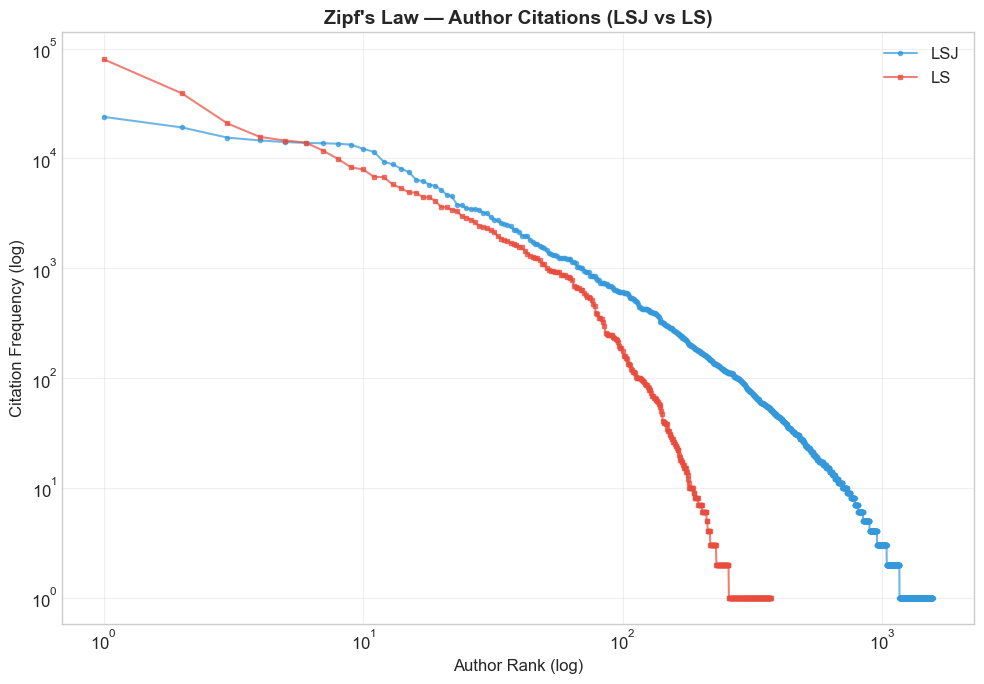

In [12]:
fig, ax = plt.subplots(figsize=(10, 7))

for d, label, color, marker in [
    (df_lsj, 'LSJ', '#3498db', 'o'),
    (df_ls,  'LS',  '#e74c3c', 's'),
]:
    ac = Counter()
    for al in d['authors']:
        ac.update(al)
    if not ac:
        continue
    ranks = np.arange(1, len(ac) + 1)
    freqs = sorted(ac.values(), reverse=True)
    ax.loglog(ranks, freqs, marker=marker, markersize=3, alpha=0.7,
              color=color, label=label, linestyle='-')

ax.set_xlabel('Author Rank (log)')
ax.set_ylabel('Citation Frequency (log)')
ax.set_title("Zipf's Law — Author Citations (LSJ vs LS)",
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Citations by Approximate Century of Author

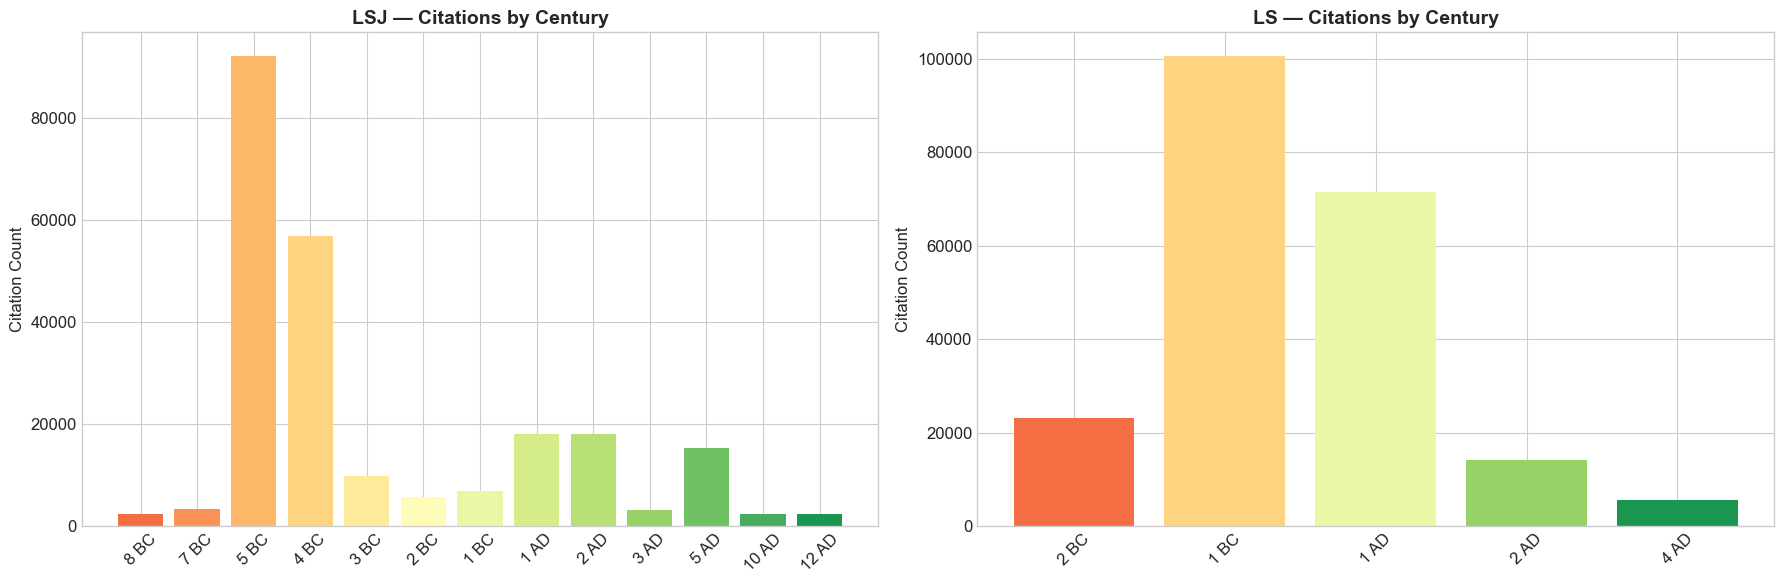

In [13]:
# Author-century mappings
lsj_author_century = {
    'Hom.': -8, 'Hes.': -7, 'Pi.': -5, 'A.': -5, 'S.': -5, 'E.': -5,
    'Ar.': -5, 'Hdt.': -5, 'Th.': -5, 'X.': -4, 'Pl.': -4, 'Arist.': -4,
    'D.': -4, 'Isoc.': -4, 'Hp.': -5, 'Thphr.': -3, 'Call.': -3,
    'A.R.': -3, 'Plb.': -2, 'D.S.': -1, 'Str.': -1, 'Ph.': 1,
    'Plu.': 1, 'Gal.': 2, 'Luc.': 2, 'Ath.': 3, 'Eust.': 12,
    'Nonn.': 5, 'Hsch.': 5, 'Suid.': 10, 'Poll.': 2,
}

ls_author_century = {
    'Cic.': -1, 'Caes.': -1, 'Sall.': -1, 'Nep.': -1, 'Varr.': -1,
    'Lucr.': -1, 'Catull.': -1, 'Verg.': -1, 'Hor.': -1, 'Ov.': 1,
    'Liv.': -1, 'Tac.': 1, 'Plin.': 1, 'Sen.': 1, 'Quint.': 1,
    'Juv.': 2, 'Mart.': 1, 'Suet.': 2, 'Gell.': 2, 'Apul.': 2,
    'Plaut.': -2, 'Ter.': -2, 'Enn.': -2, 'Cato': -2,
    'Col.': 1, 'Vitr.': -1, 'Petr.': 1, 'Stat.': 1,
    'Val. Max.': 1, 'Cels.': 1, 'Vulg.': 4, 'Aug.': 4,
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

for ax, d, mapping, title in [
    (ax1, df_lsj, lsj_author_century, 'LSJ — Citations by Century'),
    (ax2, df_ls,  ls_author_century,  'LS — Citations by Century'),
]:
    cc = Counter()
    for al in d['authors']:
        for a in al:
            if a in mapping:
                cc[mapping[a]] += 1

    if cc:
        centuries = sorted(cc.keys())
        counts = [cc[c] for c in centuries]
        labels_c = [f'{abs(c)} {"BC" if c < 0 else "AD"}' for c in centuries]
        colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(labels_c)))
        ax.bar(labels_c, counts, color=colors)
        ax.set_ylabel('Citation Count')
        ax.set_title(title, fontsize=14, fontweight='bold')
        plt.sca(ax)
        plt.xticks(rotation=45)
    else:
        ax.text(0.5, 0.5, 'No mappable authors', ha='center', va='center',
                transform=ax.transAxes, fontsize=14)
        ax.set_title(title, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 13. Comparative Density Plots

/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/matplotlib/backends/backend_agg.py:214: RuntimeWarning: Glyph 8321 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/matplotlib/backends/backend_agg.py:214: RuntimeWarning: Glyph 8320 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/matplotlib/backends/backend_agg.py:183: RuntimeWarning: Glyph 8321 missing from current font.
  font.set_text(s, 0, flags=flags)
/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/matplotlib/backends/backend_agg.py:183: RuntimeWarning: Glyph 8320 missing from current font.
  font.set_text(s, 0, flags=flags)


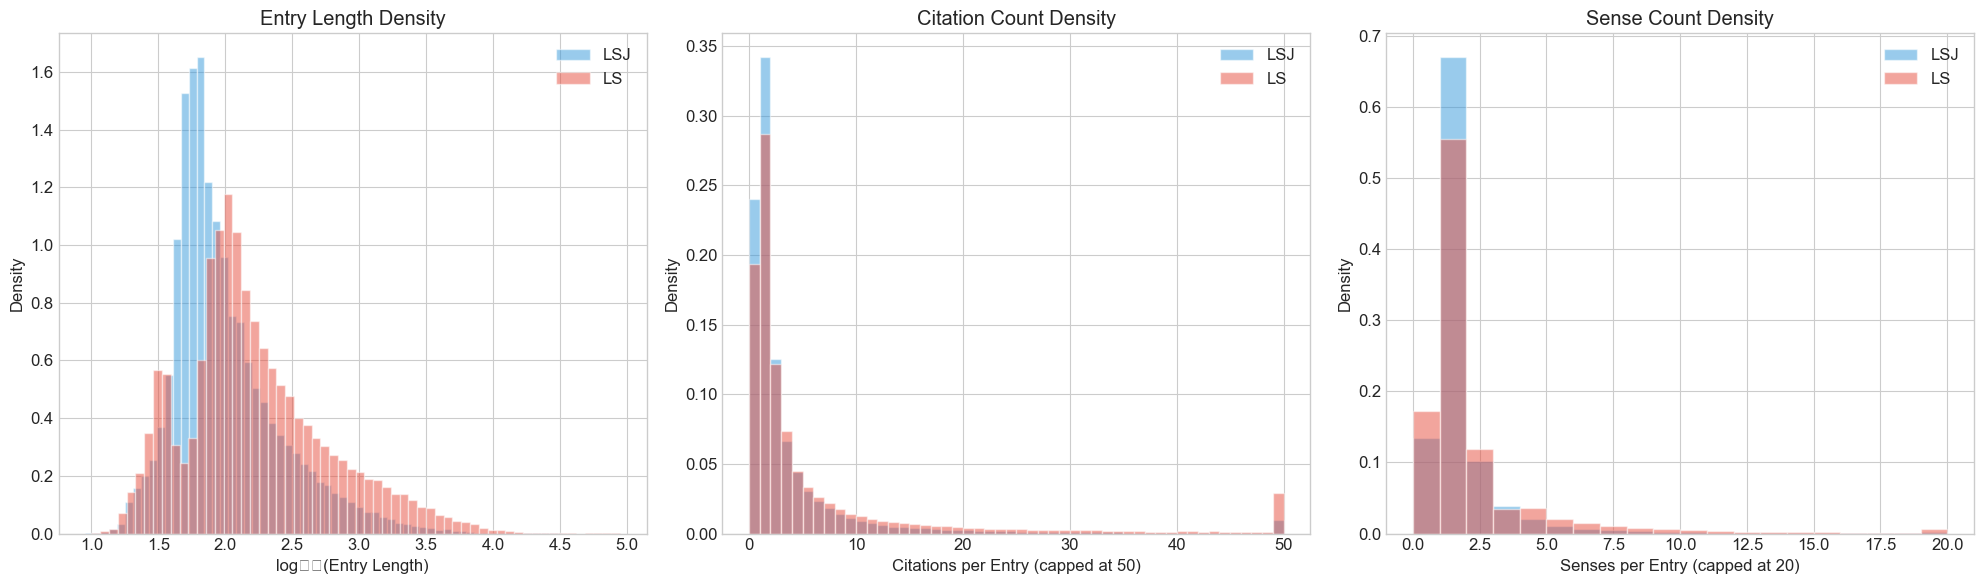

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Entry length density
ax = axes[0]
for d, label, color in [(df_lsj, 'LSJ', '#3498db'), (df_ls, 'LS', '#e74c3c')]:
    data = np.log10(d['text_len'].clip(lower=1))
    ax.hist(data, bins=60, density=True, alpha=0.5, color=color, label=label, edgecolor='white')
ax.set_xlabel('log₁₀(Entry Length)')
ax.set_ylabel('Density')
ax.set_title('Entry Length Density')
ax.legend()

# Citations per entry density
ax = axes[1]
for d, label, color in [(df_lsj, 'LSJ', '#3498db'), (df_ls, 'LS', '#e74c3c')]:
    data = d['n_bibls'].clip(upper=50)
    ax.hist(data, bins=50, density=True, alpha=0.5, color=color, label=label, edgecolor='white')
ax.set_xlabel('Citations per Entry (capped at 50)')
ax.set_ylabel('Density')
ax.set_title('Citation Count Density')
ax.legend()

# Senses per entry density
ax = axes[2]
for d, label, color in [(df_lsj, 'LSJ', '#3498db'), (df_ls, 'LS', '#e74c3c')]:
    data = d['n_senses'].clip(upper=20)
    ax.hist(data, bins=20, density=True, alpha=0.5, color=color, label=label, edgecolor='white')
ax.set_xlabel('Senses per Entry (capped at 20)')
ax.set_ylabel('Density')
ax.set_title('Sense Count Density')
ax.legend()

plt.tight_layout()
plt.show()

## 14. Shared Authors between LSJ and LS

In [15]:
lsj_authors_set = set(a for al in df_lsj['authors'] for a in al)
ls_authors_set  = set(a for al in df_ls['authors']  for a in al)

shared = lsj_authors_set & ls_authors_set

print(f'Unique authors in LSJ:  {len(lsj_authors_set):,}')
print(f'Unique authors in LS:   {len(ls_authors_set):,}')
print(f'Shared abbreviations:   {len(shared):,}')
print(f'LSJ only:               {len(lsj_authors_set - ls_authors_set):,}')
print(f'LS only:                {len(ls_authors_set - lsj_authors_set):,}')

if shared:
    # Show top shared authors with counts from each
    lsj_ac = get_author_counts(df_lsj)
    ls_ac  = get_author_counts(df_ls)
    shared_data = [(a, lsj_ac.get(a, 0), ls_ac.get(a, 0)) for a in shared]
    shared_data.sort(key=lambda x: x[1] + x[2], reverse=True)

    print(f'Top 30 shared author abbreviations:')
    print(f'  {"Author":20s} {"LSJ":>8s} {"LS":>8s} {"Total":>8s}')
    for a, lc, rc in shared_data[:30]:
        print(f'  {a:20s} {lc:8,} {rc:8,} {lc+rc:8,}')

Unique authors in LSJ:  1,566
Unique authors in LS:   372
Shared abbreviations:   85
LSJ only:               1,481
LS only:                287
Top 30 shared author abbreviations:
  Author                    LSJ       LS    Total
  id.                         4   80,066   80,070
  Cic.                      488   39,214   39,702
  Plin.                     857   20,833   21,690
  Liv.                        1   15,713   15,714
  Ov.                         8   14,558   14,566
  Plaut.                     30   13,962   13,992
  Verg.                      54   11,810   11,864
  Hor.                       14    9,901    9,915
  Quint.                    176    8,270    8,446
  Luc.                    6,192    1,777    7,969
  Tac.                        2    7,942    7,944
  Caes.                       2    6,799    6,801
  Suet.                      40    6,748    6,788
  Ter.                       22    5,810    5,832
  Sen.                        8    5,345    5,353
  Lucr.              

## 15. Structural Coverage Ratios

Percentage of entries that have at least one of each feature.

In [ ]:
features = [
    ('≥1 sense',    lambda d: (d['n_senses'] > 0).mean()),
    ('≥1 citation', lambda d: (d['n_bibls'] > 0).mean()),
    ('≥1 quote',    lambda d: (d['n_quotes'] > 0).mean()),
    ('≥1 etymology',lambda d: (d['n_etyms'] > 0).mean()),
    ('≥1 POS tag',  lambda d: d['pos'].apply(len).gt(0).mean()),
]

feat_names = [f[0] for f in features]
lsj_vals   = [f[1](df_lsj) * 100 for f in features]
ls_vals    = [f[1](df_ls)  * 100 for f in features]

x = np.arange(len(feat_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, lsj_vals, width, label='LSJ', color='#3498db', edgecolor='white')
ax.bar(x + width/2, ls_vals,  width, label='LS',  color='#e74c3c', edgecolor='white')

for i, (lv, rv) in enumerate(zip(lsj_vals, ls_vals)):
    ax.text(i - width/2, lv + 1, f'{lv:.1f}%', ha='center', fontsize=9)
    ax.text(i + width/2, rv + 1, f'{rv:.1f}%', ha='center', fontsize=9)

ax.set_ylabel('% of entries')
ax.set_title('Feature Coverage — LSJ vs LS', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(feat_names)
ax.legend()
ax.set_ylim(0, 110)
plt.tight_layout()
plt.show()